In [2]:
import pandas as pd 
# Load the dataset
df = pd.read_csv('../data/bitcoin_ohlcv.csv')

# Show first 5 rows 
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-01-01,7200.17431640625,7254.33056640625,7174.9443359375,7194.89208984375,18565664997
3,2020-01-02,6985.47021484375,7212.1552734375,6935.27001953125,7202.55126953125,20802083465
4,2020-01-03,7344.88427734375,7413.71533203125,6914.99609375,6984.4287109375,28111481032


In [ ]:
# Check Basic Info 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1828 entries, 0 to 1827
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   1828 non-null   object
 1   Close   1827 non-null   object
 2   High    1827 non-null   object
 3   Low     1827 non-null   object
 4   Open    1827 non-null   object
 5   Volume  1827 non-null   object
dtypes: object(6)
memory usage: 85.8+ KB


In [ ]:
# Check Missing Values 
df.isnull().sum()

Price     0
Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64

In [ ]:
#Check First Rows
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-01-01,7200.17431640625,7254.33056640625,7174.9443359375,7194.89208984375,18565664997
3,2020-01-02,6985.47021484375,7212.1552734375,6935.27001953125,7202.55126953125,20802083465
4,2020-01-03,7344.88427734375,7413.71533203125,6914.99609375,6984.4287109375,28111481032


In [28]:
df = df.dropna(subset=['Volatility'])

In [29]:
# Convert all columns to numeric 
df = df.apply(pd.to_numeric,errors='coerce')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 0 entries
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Price       0 non-null      float64
 1   Close       0 non-null      float64
 2   High        0 non-null      float64
 3   Low         0 non-null      float64
 4   Open        0 non-null      float64
 5   Volume      0 non-null      float64
 6   MA_7        0 non-null      float64
 7   MA_30       0 non-null      float64
 8   Returns     0 non-null      float64
 9   Volatility  0 non-null      float64
dtypes: float64(10)
memory usage: 0.0 bytes


In [31]:
# Create a new date column 
import pandas as pd

# create a date range 
df['date'] = pd.date_range(start='2020-01-01',periods=len(df),freq='D')


In [32]:
df.set_index('date', inplace=True)

In [33]:
# To check if the date column is set as index and appear on the left side or not 
df.head()

,Price,Close,High,Low,Open,Volume,MA_7,MA_30,Returns,Volatility
date,,,,,,,,,,


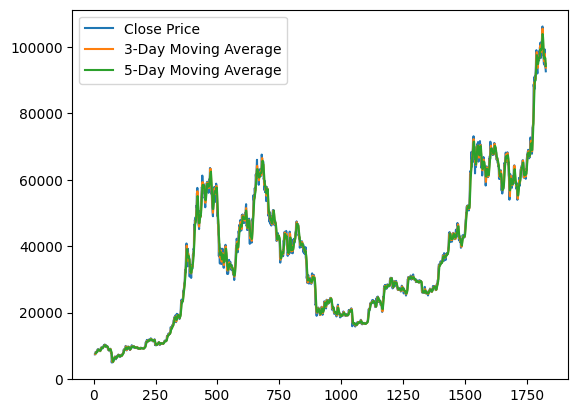

In [49]:
import matplotlib.pyplot as plt 
# Moving Average for 3 Days
df['MA_3']=df['Close'].rolling(window=3).mean()

# Now for 5 Days
df['MA_5'] = df['Close'].rolling(window=5).mean()

# Create a new graph
plt.figure() 

# plot the original price 
plt.plot(df['Close'],label = 'Close Price')

# plot the short-term trend 
plt.plot(df['MA_3'],label= '3-Day Moving Average')

# plot the long-term trend 
plt.plot(df['MA_5'],label= '5-Day Moving Average') 

# Show the labels 
plt.legend()




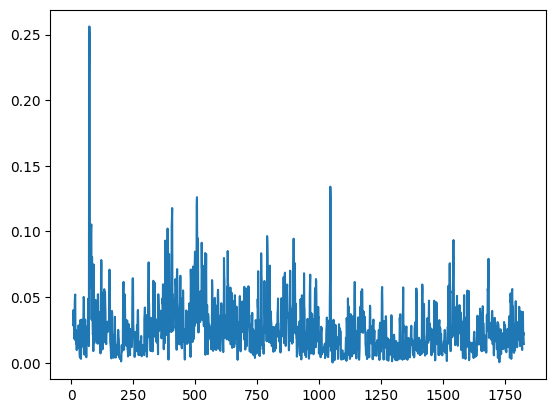

In [50]:
# # Volatility 
import matplotlib.pyplot as plt 
df['Returns'] = df['Close'].pct_change() # pct_change() calculates % changes btwn days

df['Volatility'] = df['Returns'].rolling(window=3).std()

plt.plot(df['Volatility'])


In [53]:

# Correlation 
corr = df.corr()
corr

,Price,Close,High,Low,Open,Volume,Returns,Volatility,MA_3,MA_5
Price,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Close,NaN,1.000000,0.999175,0.998971,0.998025,0.295058,0.019465,0.015090,0.998938,0.997716
High,NaN,0.999175,1.000000,0.998365,0.999090,0.309709,-0.006119,0.025779,0.999396,0.998493
Low,NaN,0.998971,0.998365,1.000000,0.998645,0.275433,-0.003736,-0.001307,0.998902,0.997736
Open,NaN,0.998025,0.999090,0.998645,1.000000,0.296425,-0.034554,0.012995,0.999539,0.998837
Volume,NaN,0.295058,0.309709,0.275433,0.296425,1.000000,-0.005990,0.401564,0.295698,0.295259
Returns,NaN,0.019465,-0.006119,-0.003736,-0.034554,-0.005990,1.000000,0.032200,-0.015877,-0.021012
Volatility,NaN,0.015090,0.025779,-0.001307,0.012995,0.401564,0.032200,1.000000,0.013664,0.015424
MA_3,NaN,0.998938,0.999396,0.998902,0.999539,0.295698,-0.015877,0.013664,1.000000,0.999453
MA_5,NaN,0.997716,0.998493,0.997736,0.998837,0.295259,-0.021012,0.015424,0.999453,1.000000


In [52]:
# Deleting the Column and Row 7 and 30
df = df.drop(columns=['MA_7','MA_30'], errors='ignore')

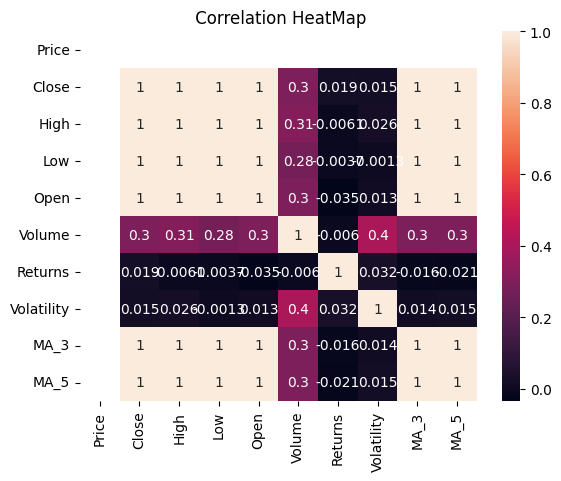

In [55]:
# Heatmap of correlation
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(corr, annot=True)
plt.title(" Correlation HeatMap")
plt.show()


In [57]:
# Predicitng future bitcoin price using ARMIA
from statsmodels.tsa.arima.model import ARIMA 
import matplotlib.pyplot as plt


In [59]:
# Select the data
data = df['Close']

# Fit ARIMA Model
model = ARIMA(data,order=(1,1,1))
model_fit = model.fit()



c:\Users\Shreyas\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Shreyas\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Shreyas\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [67]:
# Make Prediction
forecast = model_fit.forecast(steps=30)


c:\Users\Shreyas\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Shreyas\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [68]:
print(forecast)

1823    92638.459356
1824    92640.870405
1825    92639.646989
1826    92640.267775
1827    92639.952776
1828    92640.112613
1829    92640.031508
1830    92640.072663
1831    92640.051780
1832    92640.062376
1833    92640.057000
1834    92640.059728
1835    92640.058343
1836    92640.059046
1837    92640.058689
1838    92640.058870
1839    92640.058779
1840    92640.058825
1841    92640.058801
1842    92640.058813
1843    92640.058807
1844    92640.058810
1845    92640.058809
1846    92640.058810
1847    92640.058809
1848    92640.058810
1849    92640.058809
1850    92640.058809
1851    92640.058809
1852    92640.058809
Name: predicted_mean, dtype: float64


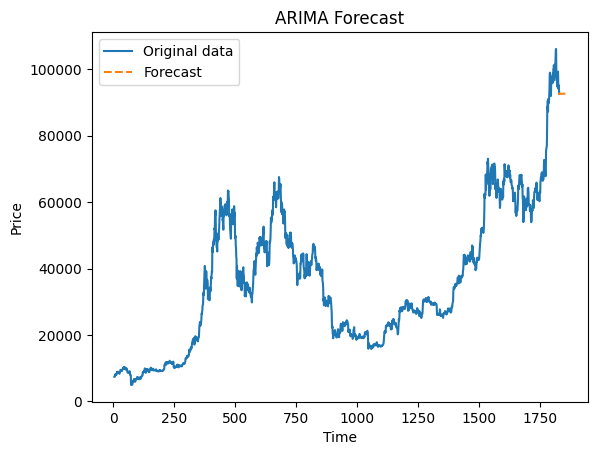

In [69]:
# Plotting the forecasted valeus 
plt.figure()

# plot the original data 
plt.plot(data,label='Original data')


# Plot Forecast 
forecast_index = range(len(data), len(data)+len(forecast))
plt.plot(forecast_index,forecast,label='Forecast',linestyle='dashed')

plt.title("ARIMA Forecast")
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


In [70]:
# Model Evualtion 
from sklearn.metrics import mean_squared_error,mean_absolute_error
import numpy as np


In [71]:
#Creating Train-Test Split
train_size = int(len(data)*0.8)
train = data[:train_size]
test = data[train_size:]


In [72]:
# Train ARIMA on Train data
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()


c:\Users\Shreyas\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Shreyas\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Shreyas\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [74]:
# Predict on TEST DATA 
predicitions = model_fit.forecast(steps=len(test))


c:\Users\Shreyas\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [75]:
# Calculate Erros 
mae = mean_absolute_error(test, predicitions)
rmse = np.sqrt(mean_squared_error(test, predicitions))

print("MAE;",mae)
print("RMSE:",rmse)




MAE; 23702.692569346702
RMSE: 27779.83127419206


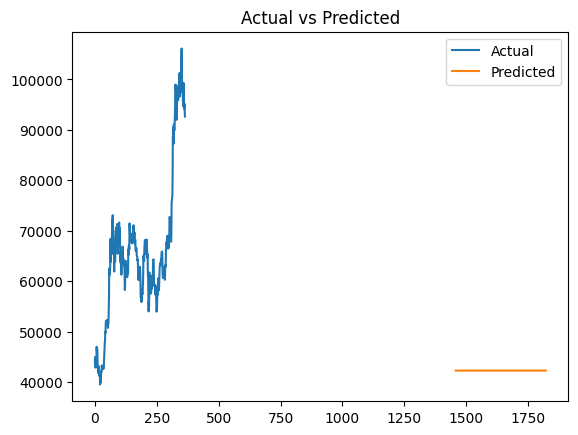

In [76]:
# Plotting real vs predicted values 
plt.figure()
plt.plot(test.values,label='Actual')
plt.plot(predicitions , label='Predicted')
plt.legend()
plt.title('Actual vs Predicted')
plt.show()


In [86]:
df_prophet.head(6)

,ds,y
0,2020-01-01,7410.656738
1,2020-01-02,7411.317383
2,2020-01-03,7769.219238
3,2020-01-04,8163.692383
4,2020-01-05,8079.862793
5,2020-01-06,7879.071289


In [ ]:
# Creating a real data column 
df['Date'] = pd.date_range(start='2020-01-01',periods=len(df),freq='D')


In [84]:
# Reset index Again
df_reset = df.reset_index()

In [85]:
df_prophet = df_reset[['Date','Close']]
df_prophet.columns =['ds','y']


In [87]:
df_prophet.head(10)

,ds,y
0,2020-01-01,7410.656738
1,2020-01-02,7411.317383
2,2020-01-03,7769.219238
3,2020-01-04,8163.692383
4,2020-01-05,8079.862793
5,2020-01-06,7879.071289
6,2020-01-07,8166.554199
7,2020-01-08,8037.537598
8,2020-01-09,8192.494141
9,2020-01-10,8144.194336


In [93]:
# TRAIN AND FORECAST USING PROPHET 
from prophet import Prophet 

# Create Model
model = Prophet () 

# Train Model
model.fit(df_prophet)

# create Future Dates
future = model.make_future_dataframe(periods=30)


15:50:43 - cmdstanpy - INFO - Chain [1] start processing
15:50:43 - cmdstanpy - INFO - Chain [1] done processing


In [94]:
# Predict
forecast = model.predict(future)  

In [95]:
# Check the Predictions
forecast[['ds','yhat']].tail()


,ds,yhat
1848,2025-01-22,92892.346022
1849,2025-01-23,93072.990885
1850,2025-01-24,93342.961509
1851,2025-01-25,93478.370837
1852,2025-01-26,93852.202856


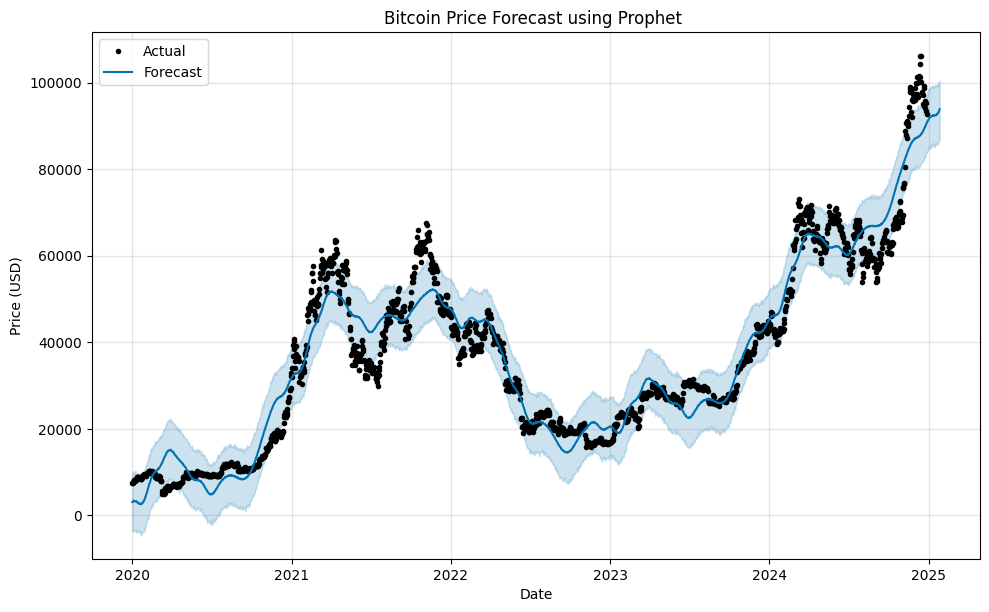

In [98]:
# Plotting the forecasted values
fig = model.plot(forecast)
plt.title('Bitcoin Price Forecast using Prophet ')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend(['Actual', 'Forecast'])
plt.grid(True)
plt.show()